In [91]:
import numpy as np

In [92]:
data = [
    [150, 7.0, 1, 'Apple'],
    [120, 6.5, 0, 'Banana'],
    [180, 7.5, 2, 'Orange'],
    [155, 7.2, 1, 'Apple'],
    [110, 6.0, 0, 'Banana'],
    [190, 7.8, 2, 'Orange'],
    [145, 7.1, 1, 'Apple'],
    [115, 6.3, 0, 'Banana']
]

In [93]:
for i in data:
    test = i[3]
    if test == "Apple":
        i[3] = 0
    elif test == "Banana":
        i[3] = 1
    else:
        i[3] = 2
X_train = [i[:3] for i in data]
y_train = [i[3] for i in data]

In [94]:
def euclidean_dist(x,y):
    return np.sqrt(np.sum((x-y)**2))
def manhattan_dist(x,y):
    return np.sum(np.abs(x-y))
def minkowski_dist(x,y,p=3):
    return np.sum((np.abs(x-y)**p)**(1/p))



In [95]:
# since the different features values are in different scales, they contribute unevenly to scores
# min max normalizes for all features to scale down and fit in [0,1]
def minmax(x):
    x = np.array(x)
    min,max = x.min(axis=0),x.max(axis=0)
    return (x-min)/(max-min+1e-8)
# normalizes cause each set of features values to have 0 mean nd std 1
def zscore(X):
    X = np.array(X, dtype=np.float32)
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean)/(std + 1e-8)
X_train = zscore(X_train)

In [115]:
class KNN:
    def __init__(self,k=3,metric="euclidean",weighted=False,p=3):
        self.k =k
        self.metric = metric
        self.weighted = weighted
        self.p = p
    def fit(self,X,y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    def distance(self,x,y):
        if self.metric == "euclidean":
            return euclidean_dist(x,y)
        elif self.metric == "manhattan":
            return manhattan_dist(x,y)
        elif self.metric == "minkowski":
            return minkowski_dist(x,y,self.p)
        
    def predict_one(self,x):
        x = np.array(x, dtype=np.float32)
        dist = np.array([self.distance(x,xi) for xi in self.X_train])
        sorted = np.argsort(dist)
        k_indices = sorted[:self.k]
        k_labels = self.y_train[k_indices]
        k_dist = dist[k_indices]

        ## new flow becomes distances -> sort -> pick top k -> compute weights (inverse of distances) 
        if self.weighted:
            # inverse of distances -> closer maps to larger weight
            weights = 1/(k_dist+1e-8)
            # classes are encoded as 0,1,2... so scores list would be 2+1 =3 here
            scores = np.zeros(np.max(self.y_train)+1)
            for i in range(len(k_labels)):
                scores[k_labels[i]] += weights[i]
            return np.argmax(scores)
        else:
            counts = np.bincount(k_labels)  # get counts of all the diff labels in the top k indices 
            return np.argmax(counts) 
    def predict(self,X):
        return np.array([self.predict_one(x) for x in X])

In [97]:
def accuracy(y_pred,y_true):
    return (np.sum(y_true==y_pred)/len(y_true)) * 100

def train_test_split(x,y,ratio=0.5):
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    split = int(n*ratio)
    train_idx = indices[:split]
    test_idx = indices[split:]
    return x[train_idx],x[test_idx],y[train_idx],y[test_idx]

In [98]:
test_data = np.array([
    [118, 6.2, 0],  # Expected: Banana
    [160, 7.3, 1],  # Expected: Apple
    [185, 7.7, 2]   # Expected: Orange
])
test_data = zscore(test_data)
model = KNN(k=3,metric="euclidean",weighted=True)
model.fit(X_train,y_train)
y_pred = model.predict(test_data)
print("Predictions :",y_pred)
labels = ["Apple","Banana","Orange"]
print([labels[i] for i in y_pred])

Predictions : [1 0 2]
['Banana', 'Apple', 'Orange']


In [99]:
# With train test split and accuracy
X_train,X_test,y_train,y_test  = train_test_split(X_train, np.array(y_train), 0.8)
model.fit(X_train,y_train)
y_pred2 = model.predict(X_test)
print("Accuracy : ",accuracy(y_pred2,y_test))

Accuracy :  100.0


In [100]:
#Unweighted vs weighted for diff k's
print("Unweighted KNN ")
for k in [1,3,5]:
    model = KNN(k=k,metric="euclidean",weighted=False)
    model.fit(X_train,y_train)
    print("k=",k,"->",model.predict(test_data))
# Weighted KNN
print("Weighted KNN")
for k in [1,3,5]:
    model = KNN(k=k,metric="euclidean",weighted=True)
    model.fit(X_train,y_train)
    print("k=",k,"->",model.predict(test_data))

Unweighted KNN 
k= 1 -> [1 0 2]
k= 3 -> [1 0 0]
k= 5 -> [0 0 0]
Weighted KNN
k= 1 -> [1 0 2]
k= 3 -> [1 0 2]
k= 5 -> [1 0 0]


In [101]:
for metric in ['euclidean', 'manhattan', 'minkowski']:
    knn_metric = KNN(k=3,metric=metric, weighted=True)
    knn_metric.fit(X_train, y_train)
    preds = knn_metric.predict(test_data)
    print(f"{metric}: {preds}")

euclidean: [1 0 2]
manhattan: [1 0 2]
minkowski: [1 0 2]


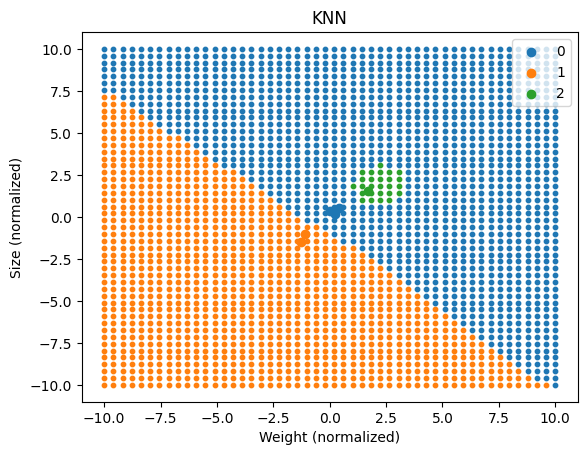

In [108]:
import matplotlib.pyplot as plt
# for a 2D plot only two features are required
X_train_2 = X_train[:, :2]
# normialze
X_train_2= zscore(X_train_2)
model = KNN(k=3, metric="euclidean", weighted=True)
model.fit(X_train_2, y_train)
# scatter the known points
for cls in np.unique(y_train):
    pts = X_train_2[y_train == cls]
    plt.scatter(pts[:,0], pts[:,1], label=cls)

# use the model to predict at discrete points to visualise the space
x_vals = np.linspace(-10, 10, 50)
y_vals = np.linspace(-10, 10, 50)
for xv in x_vals:
    for yv in y_vals:
        pred = model.predict_one([xv, yv])
        plt.scatter(xv, yv, c=f"C{pred}",s=10)

plt.xlabel("Weight (normalized)")
plt.ylabel("Size (normalized)")
plt.legend()
plt.title("KNN")
plt.show()


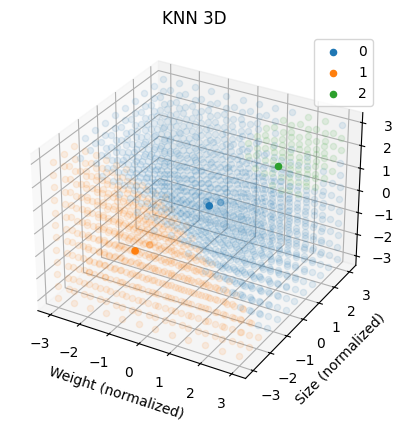

In [ ]:
# Visualsing in 3D with all three feaures
# normalize 3 features
X_train_3= zscore(X_train)

model = KNN(k=3, metric="euclidean", weighted=True)
model.fit(X_train_3, y_train)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# scatter known points
for cls in np.unique(y_train):
    pts = X_train_3[y_train == cls]
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], label=cls)

# discrete sampling
x_vals = np.linspace(-3, 3, 12)
y_vals = np.linspace(-3, 3, 12)
z_vals = np.linspace(-3, 3, 12)

for xv in x_vals:
    for yv in y_vals:
        for zv in z_vals:
            pred = model.predict_one([xv, yv, zv])
            ax.scatter(xv, yv, zv, c=f"C{pred}",alpha=0.1)

ax.set_xlabel("Weight (normalized)")
ax.set_ylabel("Size (normalized)")
ax.set_zlabel("Color (normalized)")

ax.legend()
ax.set_title("KNN 3D")
plt.show()

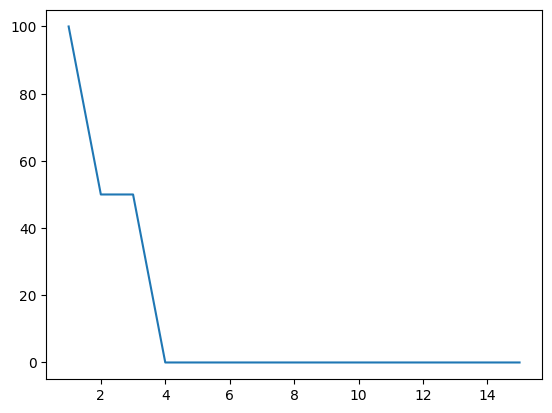

In [124]:
accuracies = []
for k in range(1, 16):
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy(y_pred,y_test))
plt.plot(range(1,16),accuracies)
plt.show()